## Parte 02 - Trilha A

Três classes (fundo / interior / fronteira entre instâncias) e/ou um mapa contínuo de distância ao fundo.
Decodificação por watershed com os interiores como marcadores. A perda das classes usa CE balanceada
ou focal (slides 74–79); a do mapa de distância usa L1 ou L2 (slide 80). Como gerar o rótulo de fronteira
a partir das máscaras individuais? Que espessura? Como pesar a classe fronteira, que é minoritária?

#### Importações

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet34, ResNet34_Weights
from torch.utils.data import Dataset, DataLoader, random_split
from skimage.segmentation import watershed
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cv2 as cv
from scipy import ndimage
from pathlib import Path
import warnings
import time



#### Configurações

In [38]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)
PATH_TRAIN = Path('../data/stage1_train')
BATCH_SIZE = 16
IMG_SIZE = 256
BOUNDARY_THICKNESS = 2
print(f'Device: {DEVICE}')

Device: xpu


#### Classes e funções

In [ ]:
# ==============================================================================
# 1. UNetTernary (3 Classes + Mapa de Distância)
# ==============================================================================
class UNetTernary(nn.Module):
	def __init__(self):
		super().__init__()
		resnet = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
		
		self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
		self.pool = resnet.maxpool
		self.enc2 = resnet.layer1
		self.enc3 = resnet.layer2
		self.enc4 = resnet.layer3

		self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
		self.dec3 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.ReLU())
		self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
		self.dec2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
		self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
		self.dec1 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
		self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
		self.dec0 = nn.Sequential(nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU())
		self.final_cls = nn.Conv2d(32, 3, kernel_size=1)
		self.final_dist = nn.Sequential(nn.Conv2d(32, 1, kernel_size=1), nn.Sigmoid())

	def forward(self, x):
		x1 = self.enc1(x)
		x2 = self.enc2(self.pool(x1))
		x3 = self.enc3(x2)
		x4 = self.enc4(x3)

		d3 = self.dec3(torch.cat([self.up3(x4), x3], dim=1))
		d2 = self.dec2(torch.cat([self.up2(d3), x2], dim=1))
		d1 = self.dec1(torch.cat([self.up1(d2), x1], dim=1))
		d0 = self.dec0(self.up0(d1))

		logits_cls = self.final_cls(d0)
		dist_pred = self.final_dist(d0)
		return logits_cls, dist_pred


# ---------------------------------------------------------------------------
# 2. Geração do rótulo ternário + mapa de distância a partir das instâncias
# ---------------------------------------------------------------------------
def generate_ternary_and_distance(instance_masks, h, w, boundary_thickness=BOUNDARY_THICKNESS):
	"""
	Como gerar o rótulo de fronteira a partir das máscaras individuais?
	- Para cada máscara de instância m_i, erodimos com conectividade-8 por `boundary_thickness` iterações;
	- O anel de fronteira de cada núcleo é: ring_i = m_i & ~eroded_i;
	- A classe FRONTEIRA tem prioridade sobre o interior na fusão.

	Que espessura?
	- 1 px tende a sumir devido ao pooling/convoluções da CNN e interpolação;
	- 4 px consome quase todo o interior em núcleos pequenos, destruindo os marcadores;
	- 2 pixels foi esoclhido .

	Mapa de Distância ao Fundo:
	- Distância euclidiana (EDT) normalizada pelo valor máximo dentro da própria instância [0, 1].
	"""
	label = np.zeros((h, w), dtype=np.int64)
	dist_map = np.zeros((h, w), dtype=np.float32)
	struct = ndimage.generate_binary_structure(2, 2)

	interiors, boundaries= [], []

	for m in instance_masks:
		m_bool = m.astype(bool)
		if m_bool.sum() == 0:
			continue

		eroded = ndimage.binary_erosion(m_bool, structure=struct, iterations=boundary_thickness)

		# Distância Euclidiana individual normalizada
		dt = ndimage.distance_transform_edt(m_bool)
		max_dt = dt.max()
		if max_dt > 0:
			dist_map = np.maximum(dist_map, dt / max_dt)

		if eroded.sum() == 0:
			center_idx = np.unravel_index(np.argmax(dt), dt.shape)
			eroded[center_idx] = True

		ring = m_bool & ~eroded
		interiors.append(eroded)
		boundaries.append(ring)


	for interior in interiors:
		label[interior] = 1  # Interior
	for ring in boundaries:
		label[ring] = 2  # Fronteira (prioridade)

	return label, dist_map


class DSB2018TernaryDataset(Dataset):
	def __init__(self,root,img_size=IMG_SIZE,boundary_thickness=BOUNDARY_THICKNESS,
			augment=None,cache_in_memory=True,cache_in_disk=True,):
		self.root = Path(root)
		self.ids = sorted([p.name for p in self.root.iterdir() if p.is_dir()])
		self.img_size = img_size
		self.boundary_thickness = boundary_thickness
		self.augment = augment
		self.cache_in_memory = cache_in_memory
		self.cache_in_disk = cache_in_disk
		self.memory_cache = {}

		self.sample_paths = []
		for img_id in self.ids:
			sdir = self.root / img_id
			img_path = sdir / 'images' / f'{img_id}.png'
			mask_paths = sorted((sdir / 'masks').glob('*.png'))
			self.sample_paths.append((img_path, mask_paths, sdir))

	def __len__(self):
		return len(self.ids)

	def _disk_cache_path(self, sample_dir):
		return sample_dir / f'cache_{self.img_size}_ternary.pt'

	def _process_from_disk(self, img_path, mask_paths):
		image = cv.imread(str(img_path), cv.IMREAD_COLOR)
		image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
		image_r = cv.resize(
				image, (self.img_size, self.img_size), interpolation=cv.INTER_LINEAR
		)

		instance_masks_r = []
		for mp in mask_paths:
			m = cv.imread(str(mp), cv.IMREAD_GRAYSCALE)
			m = cv.resize(
					m, (self.img_size, self.img_size), interpolation=cv.INTER_NEAREST
			)
			m = (m > 127).astype(np.uint8)
			if m.sum() > 0:
				instance_masks_r.append(m)

		label_r, dist_r = generate_ternary_and_distance(
				instance_masks_r,
				self.img_size,
				self.img_size,
				self.boundary_thickness,
		)

		return {
				'image': image_r,
				'label': label_r,
				'dist': dist_r,
				'instances': instance_masks_r,
		}

	def _get_cached_data(self, idx):
		if self.cache_in_memory and idx in self.memory_cache:
			return self.memory_cache[idx]

		img_path, mask_paths, sample_dir = self.sample_paths[idx]
		disk_cache = self._disk_cache_path(sample_dir)

		if self.cache_in_disk and disk_cache.exists():
			data = torch.load(disk_cache, weights_only=False)
		else:
			data = self._process_from_disk(img_path, mask_paths)
			if self.cache_in_disk:
				torch.save(data, disk_cache)

		if self.cache_in_memory:
			self.memory_cache[idx] = data
		return data

	def __getitem__(self, idx):
		data = self._get_cached_data(idx)
		img_id = self.ids[idx]

		image_r = data['image'].copy()
		label_r = data['label'].copy()
		dist_r = data['dist'].copy()
		instance_masks_r = data['instances']

		if self.augment is not None:
			aug = self.augment(image=image_r, masks=[label_r, dist_r])
			image_r = aug['image']
			label_r, dist_r = aug['masks']

		image_t = torch.from_numpy(image_r / 255.0).permute(2, 0, 1).float()
		label_t = torch.from_numpy(label_r).long()
		dist_t = torch.from_numpy(dist_r).unsqueeze(0).float()

		return image_t, label_t, dist_t, instance_masks_r, img_id


def split(n, p=0.2):
	n_val = int(p * n)
	n_train = n - n_val
	return [n_train, n_val]


def collate_fn_ternary(batch):
	images = torch.stack([b[0] for b in batch])
	labels = torch.stack([b[1] for b in batch])
	dists = torch.stack([b[2] for b in batch])
	instances = [b[3] for b in batch]
	ids = [b[4] for b in batch]
	return images, labels, dists, instances, ids


# ---------------------------------------------------------------------------
# 3. Pesos de classe (a fronteira é minoritária) — balanceamento por frequência mediana (median frequency balancing)
# ---------------------------------------------------------------------------
def compute_class_weights(loader, num_classes=3):
	"""
	Como pesar a classe fronteira, que é minoritária?
	- Aplica balanceamento por Frequência Mediana (Median Frequency Balancing): w_c = median(freq) / freq_c.
	"""
	counts = np.zeros(num_classes, dtype=np.float64)
	for _, labels, _, _, _ in loader:
		for c in range(num_classes):
			counts[c] += (labels == c).sum().item()
	freq = counts / counts.sum()
	weights = np.median(freq) / np.clip(freq, 1e-12, None)
	return torch.tensor(weights, dtype=torch.float32)


# ==============================================================================
# 3. FUNÇÕES DE PERDA (LOSSES)
# ==============================================================================
def focal_loss(logits, targets, weight=None, gamma=2.0):
	logpt = F.log_softmax(logits, dim=1)
	ce = F.nll_loss(logpt, targets, weight=weight, reduction='none')
	pt = logpt.gather(1, targets.unsqueeze(1)).squeeze(1).exp()
	focal_term = (1.0 - pt).clamp(min=0) ** gamma
	return (focal_term * ce).mean()


def combined_loss(logits, targets, pred_dist, targets_dist,
		weights,use_focal=True,dist_weight=1.0):
	if use_focal:
		l_cls = focal_loss(logits, targets, weight=weights)
	else:
		l_cls = F.cross_entropy(logits, targets, weight=weights)

	l_dist = F.l1_loss(pred_dist, targets_dist)
	total = l_cls + dist_weight * l_dist
	return total, l_cls.item(), l_dist.item()

# ==============================================================================
# 4. TREINAMENTO COM HISTÓRICO
# ==============================================================================
def train_model_ternary(model,train_loader,val_loader,
		class_weights,epochs=10,lr=1e-3,dist_weight=1.0):
	optimizer = torch.optim.Adam(model.parameters(), lr=lr)
	scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
			optimizer, mode='min', factor=0.5, patience=2
	)
	history = {
			'train_loss': [],
			'val_loss': [],
			'val_cls_loss': [],
			'val_dist_loss': [],
	}
	best_val_loss = float('inf')

	class_weights = class_weights.to(DEVICE)

	for epoch in range(epochs):
		model.train()
		running_train = torch.tensor(0.0, device=DEVICE)

		for images, labels, dists, _, _ in train_loader:
			images = images.to(DEVICE, non_blocking=True)
			labels = labels.to(DEVICE, non_blocking=True)
			dists = dists.to(DEVICE, non_blocking=True)

			optimizer.zero_grad()
			logits_cls, dist_pred = model(images)
			loss, _, _ = combined_loss(
					logits_cls,
					labels,
					dist_pred,
					dists,
					class_weights,
					dist_weight=dist_weight,
			)
			loss.backward()
			optimizer.step()
			running_train += loss.detach() * images.size(0)
		train_loss = running_train.item() / len(train_loader.dataset)

		model.eval()
		running_val = torch.tensor(0.0, device=DEVICE)
		running_cls = torch.tensor(0.0, device=DEVICE)
		running_dist = torch.tensor(0.0, device=DEVICE)
		
		with torch.no_grad():
			for images, labels, dists, _, _ in val_loader:
				images = images.to(DEVICE, non_blocking=True)
				labels = labels.to(DEVICE, non_blocking=True)
				dists = dists.to(DEVICE, non_blocking=True)

				logits_cls, dist_pred = model(images)
				loss, l_cls, l_dist = combined_loss(
						logits_cls,
						labels,
						dist_pred,
						dists,
						class_weights,
						dist_weight=dist_weight,
				)
				running_val += loss.detach() * images.size(0)
				running_cls += l_cls * images.size(0)
				running_dist += l_dist * images.size(0)

		n_val = len(val_loader.dataset)
		val_loss = running_val.item() / n_val
		val_cls = running_cls.item() / n_val
		val_dist = running_dist.item() / n_val

		scheduler.step(val_loss)
		history['train_loss'].append(train_loss)
		history['val_loss'].append(val_loss)
		history['val_cls_loss'].append(val_cls)
		history['val_dist_loss'].append(val_dist)

		print(
				f'Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val'
				f' Loss: {val_loss:.4f} (Cls: {val_cls:.4f}, Dist: {val_dist:.4f})'
		)

		if val_loss < best_val_loss:
			best_val_loss = val_loss
			torch.save(model.state_dict(), 'best_model_ternary.pt')

	return history



# ==============================================================================
# 5. DECODIFICAÇÃO POR WATERSHED MARCADO E AVALIAÇÃO DE INSTÂNCIAS
# ==============================================================================
def decode_watershed(
		class_probs,
		dist_map=None,
		interior_thresh=0.4,
		fg_thresh=0.5,
		min_marker_size=5,
):
	"""Decodificação por Watershed Marcado:

	1. Marcadores: Componentes conexos do Interior binarizado.
	2. Máscara de Foreground: Regiões de (Interior + Fronteira).
	3. Relevo de Inundação: Inverso da distância contínua (-dist_map) ou do
	interior (-prob_interior).
	"""
	p_bg, p_interior, p_boundary = class_probs

	# 1. Marcadores das sementes
	marker_bin = p_interior > interior_thresh
	labeled_markers, num_markers = ndimage.label(
			marker_bin, structure=np.ones((3, 3))
	)

	for i in range(1, num_markers + 1):
		if (labeled_markers == i).sum() < min_marker_size:
			labeled_markers[labeled_markers == i] = 0

	if labeled_markers.max() == 0:
		return []
		
	# 2. Máscara que impede invasão do fundo
	fg_mask = (p_interior + p_boundary) > fg_thresh

	# 3. Superfície topográfica invertida (centros são vales, bordas são cristas)
	elevation = -dist_map if dist_map is not None else -p_interior

	ws_labels = watershed(elevation, markers=labeled_markers, mask=fg_mask)

	pred_masks = []
	for i in range(1, ws_labels.max() + 1):
		inst = (ws_labels == i).astype(np.uint8)
		if inst.sum() >= min_marker_size:
			pred_masks.append(inst)

	return pred_masks


@torch.no_grad()
def evaluate_instances_watershed(
		model,
		loader,
		interior_thresh=0.4,
		fg_thresh=0.5,
		min_marker_size=5,
		k_samples=6,
):
	"""Avaliação idêntica à Parte 1: matching guloso por IoU decrescente."""
	model.eval()
	n_threshold = len(IOU_THRESHOLDS)
	tp_total = np.zeros(n_threshold)
	denom_total = np.zeros(n_threshold)

	count_errors = []
	densities = []
	per_image_aps = []
	samples = []

	for images, _, _, instance_masks_batch, _ in loader:
		images = images.to(DEVICE)
		logits_cls, dist_pred = model(images)
		probs_batch = F.softmax(logits_cls, dim=1).cpu().numpy()
		dists_batch = dist_pred.squeeze(1).cpu().numpy()

		for b in range(images.size(0)):
			pred_masks = decode_watershed(
					probs_batch[b],
					dists_batch[b],
					interior_thresh=interior_thresh,
					fg_thresh=fg_thresh,
					min_marker_size=min_marker_size,
			)
			gt_masks = instance_masks_batch[b]
			n_pred, n_gt = len(pred_masks), len(gt_masks)

			count_err = abs(n_pred - n_gt)
			count_errors.append(count_err)
			densities.append(n_gt)

			img_np = images[b].cpu().numpy().transpose(1, 2, 0)
			samples.append((count_err, img_np, gt_masks, pred_masks))

			if n_pred == 0 and n_gt == 0:
				per_image_aps.append(1.0)
				continue
			if n_pred == 0 or n_gt == 0:
				denom_total += n_pred + n_gt
				per_image_aps.append(0.0)
				continue

			# Matriz de IoU Vetorizada
			pred_flat = np.array(pred_masks, dtype=np.int32).reshape(n_pred, -1)
			gt_flat = np.array(gt_masks, dtype=np.int32).reshape(n_gt, -1)
			inter = np.dot(pred_flat, gt_flat.T)
			area_pred = pred_flat.sum(axis=1)[:, np.newaxis]
			area_gt = gt_flat.sum(axis=1)[np.newaxis, :]
			union = area_pred + area_gt - inter
			iou_matrix = inter / np.maximum(union, 1e-6)

			pairs = [
					(iou_matrix[i, j], i, j)
					for i in range(n_pred)
					for j in range(n_gt)
					if iou_matrix[i, j] > 0
			]
			pairs.sort(key=lambda x: -x[0])

			img_aps = np.zeros(n_threshold)
			for k, t in enumerate(IOU_THRESHOLDS):
				matched_pred, matched_gt = set(), set()
				tp = 0
				for iou, i, j in pairs:
					if iou < t:
						break
					if i not in matched_pred and j not in matched_gt:
						matched_pred.add(i)
						matched_gt.add(j)
						tp += 1
				fp = n_pred - tp
				fn = n_gt - tp
				denom = tp + fp + fn
				img_aps[k] = tp / denom if denom > 0 else 1.0

				tp_total[k] += tp
				denom_total[k] += denom

			per_image_aps.append(float(img_aps.mean()))

	aps = np.where(denom_total > 0, tp_total / denom_total, 1.0)
	mAP = float(np.mean(aps))
	samples.sort(key=lambda s: -s[0])
	return mAP, aps, count_errors, densities, per_image_aps, samples[:k_samples]


# ==============================================================================
# 6. FUNÇÃO SOLICITADA: PLOT DAS MÁSCARAS TERNÁRIAS (FUNDO, INTERIOR E BORDA)
# ==============================================================================
from matplotlib.colors import ListedColormap


def plot_ternary_masks(model, loader, n_samples=4):
	"""NOVA FUNÇÃO SOLICITADA:

	Visualiza detalhadamente as predições intermediárias ternárias e contínuas:
	- Linha 1: Imagem Original
	- Linha 2: Mapa de Distância Contínuo (Predito)
	- Linha 3: Rótulo Ternário Gabarito (GT)
	- Linha 4: Rótulo Ternário Predito (Argmax da CNN)
	- Linha 5: Instâncias Finais Segmentadas pelo Watershed
	"""
	model.eval()
	cmap_ternary = ListedColormap(['#1a1a1a', '#2b83ba', '#d7191c'])
	legend_elements = [
			mpatches.Patch(color='#1a1a1a', label='0: Fundo'),
			mpatches.Patch(color='#2b83ba', label='1: Interior'),
			mpatches.Patch(color='#d7191c', label='2: Fronteira'),
	]

	images, labels, dists, instances, ids = next(iter(loader))
	images = images.to(DEVICE)

	with torch.no_grad():
		logits_cls, dist_pred = model(images)
		probs = F.softmax(logits_cls, dim=1).cpu().numpy()
		pred_ternary = np.argmax(probs, axis=1)
		dist_pred_np = dist_pred.squeeze(1).cpu().numpy()

	fig, axes = plt.subplots(
			5, n_samples, figsize=(4 * n_samples, 16), squeeze=False
	)
	fig.suptitle(
			'Análise da Representação Ternária e Watershed (Parte 2)',
			fontsize=14,
			fontweight='bold',
	)

	cmap_inst = plt.get_cmap('prism').copy()
	cmap_inst.set_bad('black')

	for idx in range(min(n_samples, images.size(0))):
		img_show = images[idx].cpu().numpy().transpose(1, 2, 0)
		gt_ternary = labels[idx].numpy()
		pred_t = pred_ternary[idx]
		pred_d = dist_pred_np[idx]

		# Decodifica instâncias com watershed para visualização
		instances_pred = decode_watershed(probs[idx], pred_d)
		label_ws = np.zeros(img_show.shape[:2], dtype=np.int32)
		for i, m in enumerate(instances_pred, start=1):
			label_ws[m.astype(bool)] = i
		ws_masked = np.ma.masked_where(label_ws == 0, label_ws)

		# 1. Original
		axes[0, idx].imshow(img_show)
		axes[0, idx].set_title(f'Original: {ids[idx][:8]}')
		axes[0, idx].axis('off')

		# 2. Distância Predita
		im_d = axes[1, idx].imshow(pred_d, cmap='viridis', vmin=0, vmax=1)
		axes[1, idx].set_title('Distância ao Fundo (Predita)')
		axes[1, idx].axis('off')

		# 3. Gabarito Ternário
		axes[2, idx].imshow(
				gt_ternary, cmap=cmap_ternary, vmin=0, vmax=2, interpolation='nearest'
		)
		axes[2, idx].set_title('Gabarito Ternário (GT)')
		axes[2, idx].axis('off')

		# 4. Predição Ternária
		axes[3, idx].imshow(
				pred_t, cmap=cmap_ternary, vmin=0, vmax=2, interpolation='nearest'
		)
		axes[3, idx].set_title('Predição Ternária (CNN)')
		axes[3, idx].axis('off')

		# 5. Instâncias Watershed
		axes[4, idx].imshow(ws_masked, cmap=cmap_inst, interpolation='nearest')
		axes[4, idx].set_title(f'Instâncias Watershed ({len(instances_pred)})')
		axes[4, idx].axis('off')

	fig.legend(
			handles=legend_elements,
			loc='lower center',
			ncol=3,
			bbox_to_anchor=(0.5, 0.01),
			frameon=True,
	)
	plt.tight_layout(rect=[0, 0.03, 1, 0.98])
	plt.show()




# ==============================================================================
# 7. FUNÇÕES DE PLOTAGEM (CURVAS, DENSIDADE E COMPARAÇÃO)
# ==============================================================================
def plot_training_curves_ternary(history):
	fig, axes = plt.subplots(1, 2, figsize=(12, 4))
	axes[0].plot(history['train_loss'], label='Treino (Total)')
	axes[0].plot(history['val_loss'], label='Validação (Total)')
	axes[0].set_title('Evolução da Loss Combinada')
	axes[0].set_xlabel('Época')
	axes[0].set_ylabel('Loss')
	axes[0].grid(alpha=0.3)
	axes[0].legend()

	axes[1].plot(history['val_cls_loss'], label='Val Classif. (Focal)')
	axes[1].plot(history['val_dist_loss'], label='Val Distância (L1)')
	axes[1].set_title('Componentes da Loss de Validação')
	axes[1].set_xlabel('Época')
	axes[1].grid(alpha=0.3)
	axes[1].legend()

	plt.tight_layout()
	plt.show()



def plot_metrics(all_mAPs, all_count_errors, all_densities):
    print(f"Média global mAP: {np.mean(all_mAPs):.4f}")
    print(f"Média global Erro Absoluto de Contagem: {np.mean(all_count_errors):.4f}")

    corr_ap = np.corrcoef(densities, per_image_aps)[0, 1]
    print(f'Correlação (densidade x mAP por imagem): {corr_ap:.3f}')

    corr_err = np.corrcoef(densities, count_errors)[0, 1]
    print(f'Correlação (densidade x erro de contagem): {corr_err:.3f}')

    fig, ax = plt.subplots(1, 2, figsize=(10, 6))

    color = 'tab:blue'
    ax[0].set_xlabel('Densidade de Objetos (Qtd. de Instâncias Reais)')
    ax[0].set_ylabel('mAP (Threshold 0.5 a 0.95)', color=color)
    ax[0].scatter(all_densities, all_mAPs, color=color, alpha=0.6, label='mAP')
    ax[0].tick_params(axis='y', labelcolor=color)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['top'].set_visible(False)
    ax[0].set_title("Quantificação de Falhas: Desempenho vs. Densidade", fontsize=10, fontweight='bold')

    color = 'tab:red'
    ax[1].set_ylabel('Erro Absoluto de Contagem', color=color)
    ax[1].scatter(all_densities, all_count_errors, color=color, alpha=0.6, label='Erro de Contagem')
    ax[1].set_xlabel('Densidade de Objetos (Qtd. de Instâncias Reais)')
    ax[1].tick_params(axis='y', labelcolor=color)
    ax[1].spines['right'].set_visible(False)
    ax[1].spines['top'].set_visible(False)
    ax[1].set_title("Quantificação de Falhas: Desempenho vs. Densidade", fontsize=10, fontweight='bold')
    plt.grid(False)
    fig.tight_layout()
    plt.show()


def masks_to_label(masks, shape):
    """
    Converte uma LISTA de máscaras binárias (formato usado por
    evaluate_instances/greedy_match) num único MAPA DE RÓTULOS (H,W),
    formato que cmap='nipy_spectral' espera pra colorir por instância:
    0 = fundo, 1 = instância 1, 2 = instância 2, ...
 
    Se duas máscaras se sobrepuserem (não deveria acontecer com
    componentes conexos, mas por segurança), a última da lista "ganha"
    o pixel disputado.
    """
    label = np.zeros(shape, dtype=np.int32)
    for i, m in enumerate(masks, start=1):
        label[m.astype(bool)] = i
    return label

    
def plot_samples(samples, part: int = 1):
    """
    Layout: uma coluna por amostra, 3 linhas (original / gabarito / predição),
    cada instância com uma cor distinta via nipy_spectral (fundo forçado a
    preto com máscara, pra não ficar colorido também).
    """
    n_samples = len(samples)
    fig, axes = plt.subplots(3, n_samples, figsize=(4 * n_samples, 12), squeeze=False)
    fig.suptitle(f"Amostra de {n_samples} Resultados - Parte {part}", fontsize=14, fontweight='bold')
 
    cmap = plt.get_cmap('prism').copy()
    cmap.set_bad('black')  # fundo (rótulo 0, mascarado) sempre preto
 
    for idx, (err, img, gt_masks, pred_masks) in enumerate(samples):
        H, W = img.shape[:2]
        gt_label = masks_to_label(gt_masks, (H, W))
        pred_label = masks_to_label(pred_masks, (H, W))
 
        gt_masked = np.ma.masked_where(gt_label == 0, gt_label)
        pred_masked = np.ma.masked_where(pred_label == 0, pred_label)

        axes[0, idx].imshow(img)
        axes[0, idx].set_title("Original")
        axes[0, idx].axis('off')

        axes[1, idx].imshow(gt_masked, cmap=cmap, interpolation='nearest')
        axes[1, idx].set_title(f"Gabarito (Instâncias: {len(gt_masks)})")
        axes[1, idx].axis('off')
 
        axes[2, idx].imshow(pred_masked, cmap=cmap, interpolation='nearest')
        axes[2, idx].set_title(f"Predição (Instâncias: {len(pred_masks)}) | Erro: {err}")
        axes[2, idx].axis('off')
 
    plt.tight_layout()
    plt.show()


#### Inicialização

In [40]:
model = UNetTernary().to(DEVICE)
full_ds = DSB2018TernaryDataset(PATH_TRAIN)
train_ds, val_ds = random_split(full_ds, split(len(full_ds)), generator=torch.Generator().manual_seed(42))
print(f'Train: {len(train_ds)} amostras | Val: {len(val_ds)} amostras')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)

class_weights = compute_class_weights(train_loader)
print(f'Pesos das classes [Fundo, Interior, Borda]: {class_weights.tolist()}')

Train: 536 amostras | Val: 134 amostras
Pesos das classes [Fundo, Interior, Borda]: [0.08267134428024292, 1.0, 1.0860235691070557]


#### Treinamento


Epoch 01/10 | Train Loss: 0.5198 | Val Loss: 0.4055 (Cls: 0.1152, Dist: 0.2903)
Epoch 02/10 | Train Loss: 0.2253 | Val Loss: 0.1792 (Cls: 0.1014, Dist: 0.0779)
Epoch 03/10 | Train Loss: 0.1321 | Val Loss: 0.1252 (Cls: 0.0773, Dist: 0.0479)
Epoch 04/10 | Train Loss: 0.1016 | Val Loss: 0.0934 (Cls: 0.0569, Dist: 0.0365)
Epoch 05/10 | Train Loss: 0.0762 | Val Loss: 0.0759 (Cls: 0.0429, Dist: 0.0329)
Epoch 06/10 | Train Loss: 0.0628 | Val Loss: 0.0633 (Cls: 0.0331, Dist: 0.0302)
Epoch 07/10 | Train Loss: 0.0559 | Val Loss: 0.0587 (Cls: 0.0294, Dist: 0.0293)
Epoch 08/10 | Train Loss: 0.0530 | Val Loss: 0.0568 (Cls: 0.0280, Dist: 0.0288)
Epoch 09/10 | Train Loss: 0.0521 | Val Loss: 0.0579 (Cls: 0.0296, Dist: 0.0283)
Epoch 10/10 | Train Loss: 0.0495 | Val Loss: 0.0568 (Cls: 0.0286, Dist: 0.0282)
Tempo de treino: 6.91 minutos


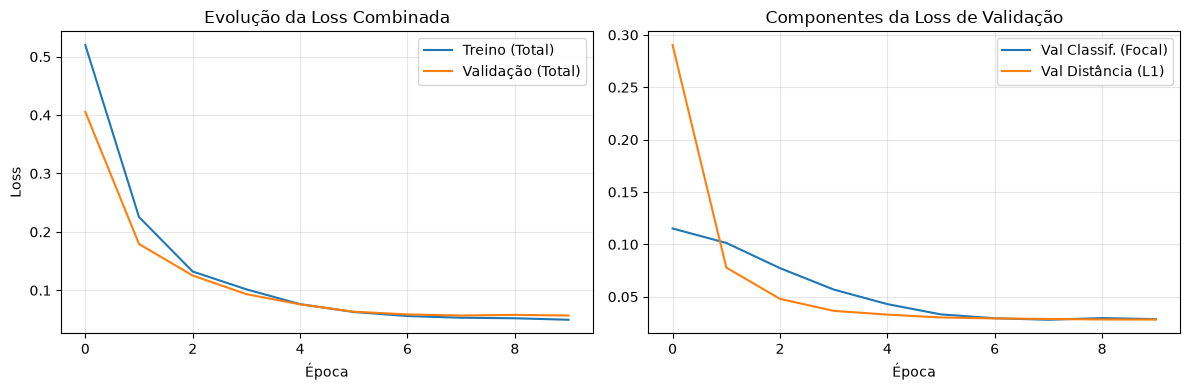

In [41]:
start_time = time.time()
history = train_model_ternary(
		model,
		train_loader,
		val_loader,
		class_weights,
		epochs=10,
		lr=1e-4,
		dist_weight=1.0,
)
print(f'Tempo de treino: {(time.time() - start_time) / 60:.2f} minutos')
plot_training_curves_ternary(history)

#### Validação e plotagem

mAP (IoU 0.50:0.95): 0.0834
Erro Absoluto Médio de Contagem: 18.4627


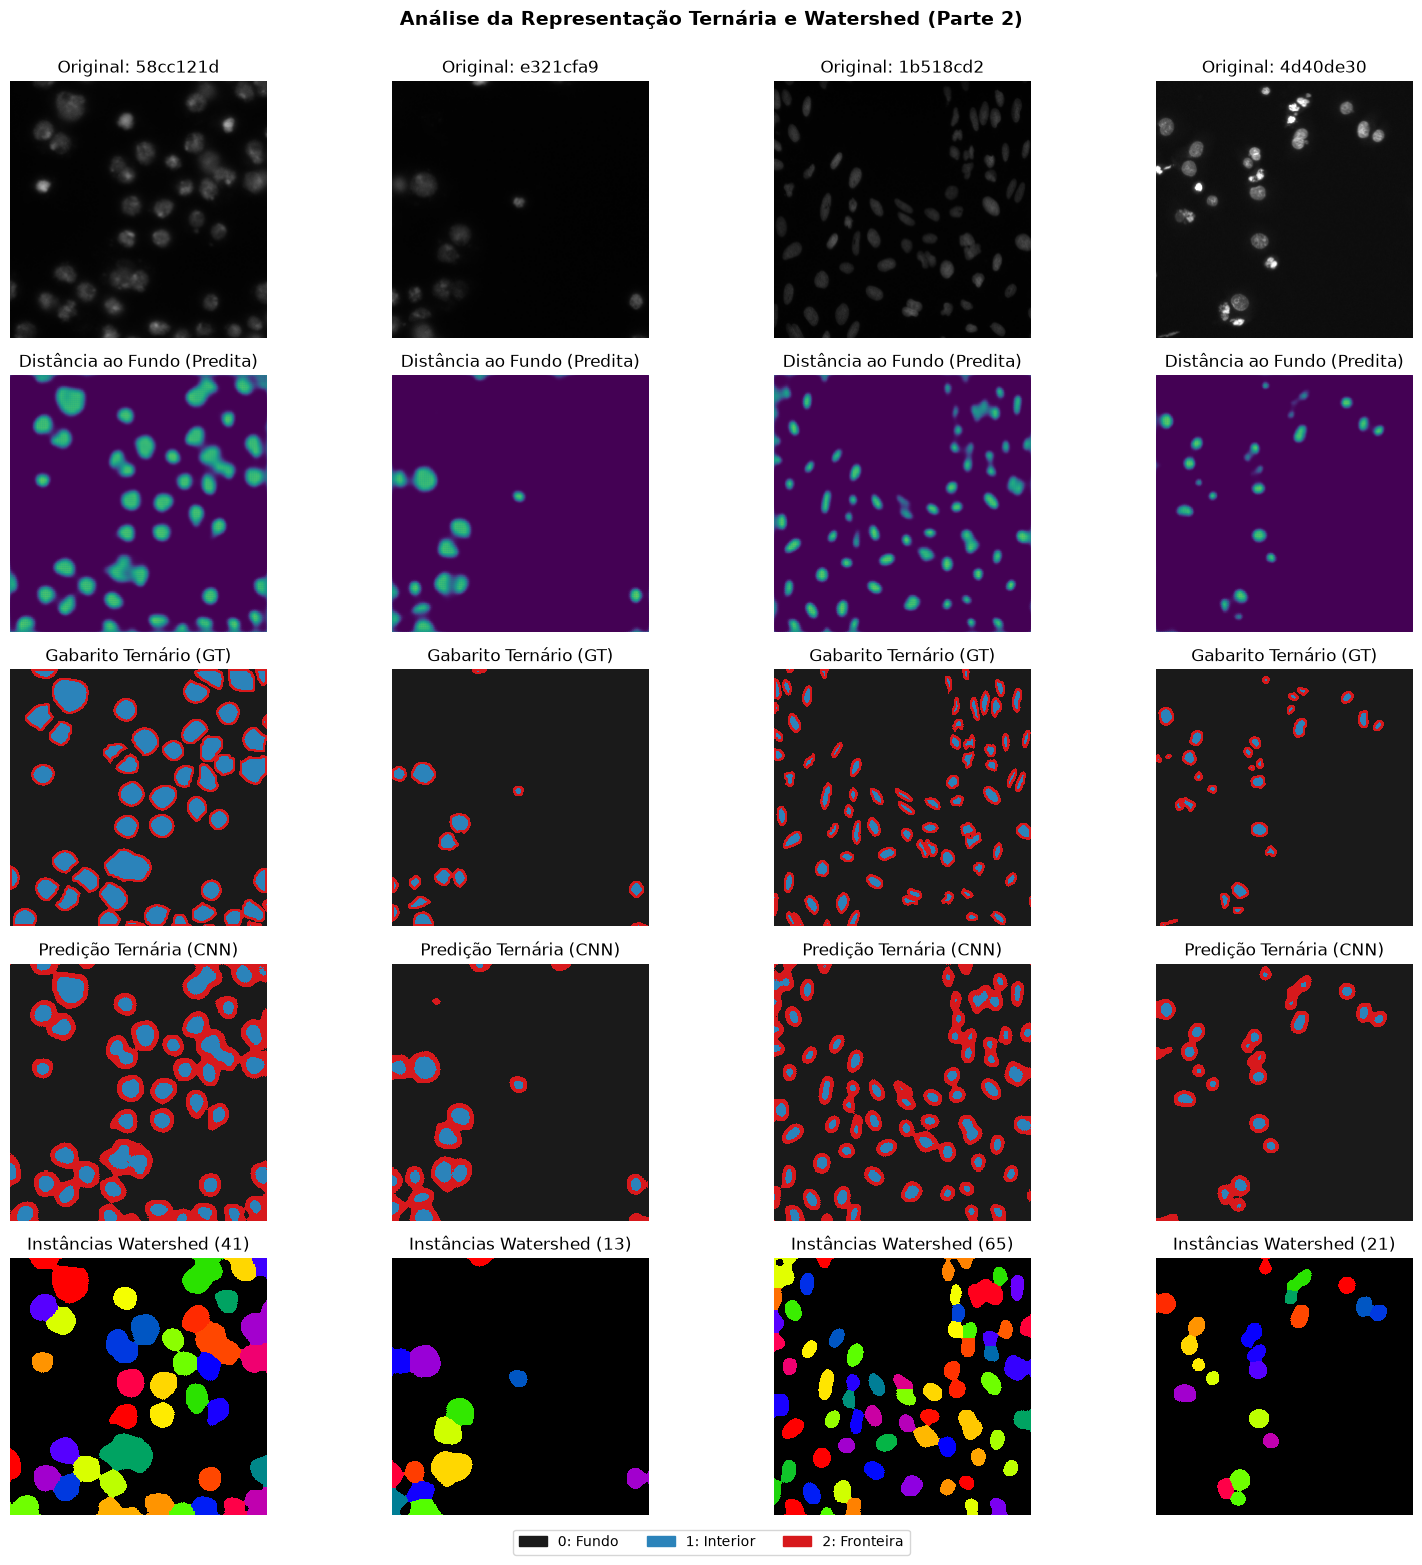

In [42]:
model.load_state_dict(torch.load('best_model_ternary.pt', map_location=DEVICE))
mAP, aps, count_errors, densities, per_image_aps, samples = evaluate_instances_watershed(model, val_loader)

print(f'mAP (IoU 0.50:0.95): {mAP:.4f}')
print(f'Erro Absoluto Médio de Contagem: {np.mean(count_errors):.4f}')

# 6. Nova visualização solicitada das máscaras ternárias
plot_ternary_masks(model, val_loader)


Média global mAP: 0.1570
Média global Erro Absoluto de Contagem: 18.4627
Correlação (densidade x mAP por imagem): -0.359
Correlação (densidade x erro de contagem): 0.902


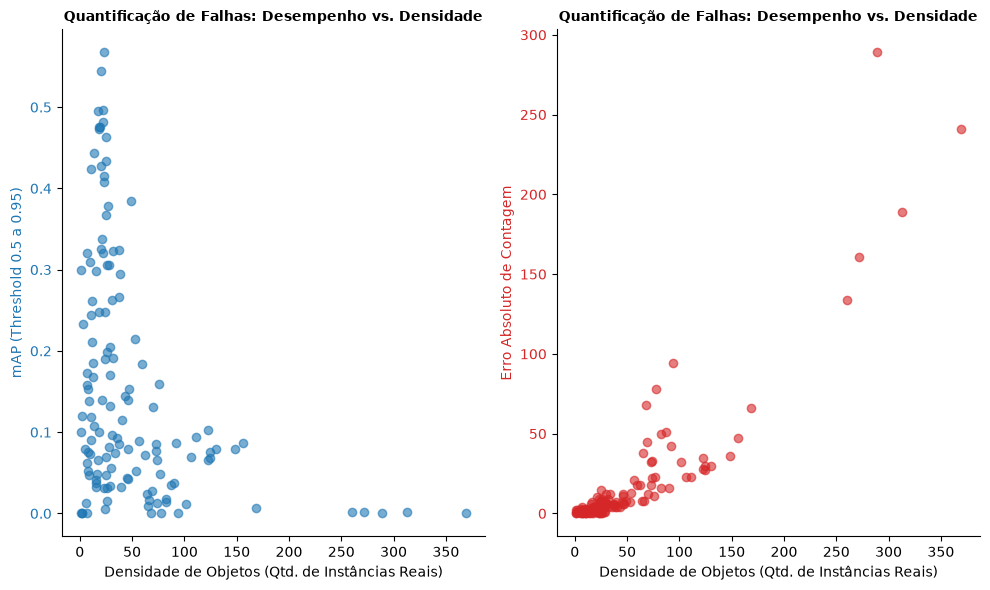

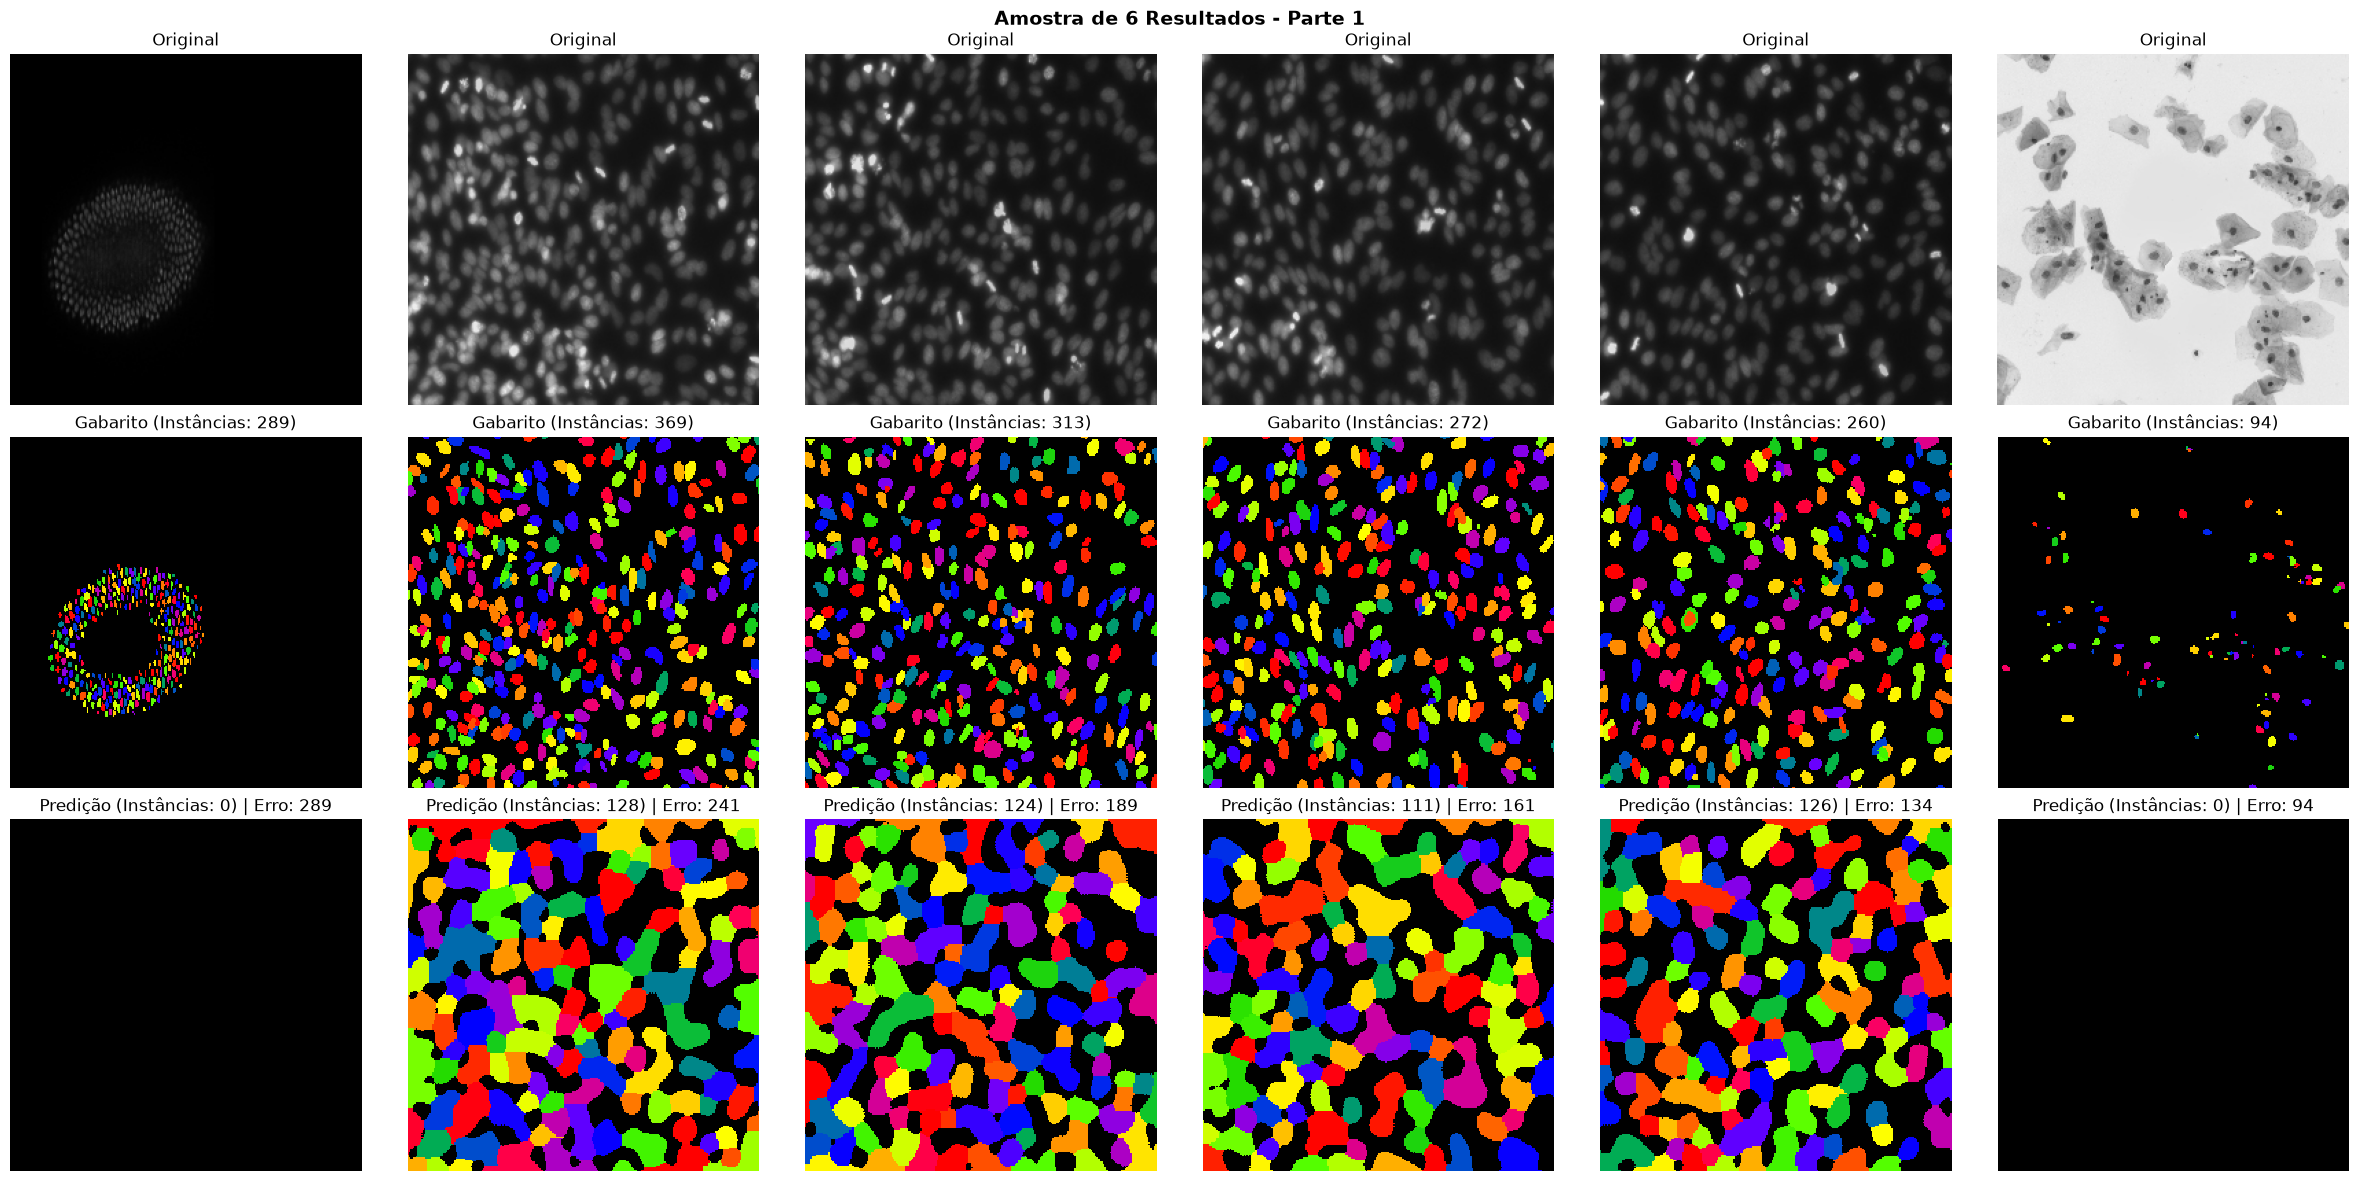

In [43]:
plot_metrics(per_image_aps, count_errors, densities)
plot_samples(samples)